# 1.Multi Layer Perceptron from Scratch

## Architecture: Input Layer → Hidden Layer 1 → Hidden Layer 2 → Output Layer
Dataset: Iris Flowers (3 classes, 4 features) 

Training samples : 120
Test samples     : 30
Input features   : 4
Output classes   : 3

🚀 Training Started...

Epoch  100/1000  |  Loss: 0.2573  |  Accuracy: 96.7%
Epoch  200/1000  |  Loss: 0.1580  |  Accuracy: 98.3%
Epoch  300/1000  |  Loss: 0.1121  |  Accuracy: 97.5%
Epoch  400/1000  |  Loss: 0.0844  |  Accuracy: 98.3%
Epoch  500/1000  |  Loss: 0.0690  |  Accuracy: 98.3%
Epoch  600/1000  |  Loss: 0.0591  |  Accuracy: 98.3%
Epoch  700/1000  |  Loss: 0.0523  |  Accuracy: 98.3%
Epoch  800/1000  |  Loss: 0.0475  |  Accuracy: 98.3%
Epoch  900/1000  |  Loss: 0.0439  |  Accuracy: 98.3%
Epoch 1000/1000  |  Loss: 0.0409  |  Accuracy: 98.3%

✅ Final Train Accuracy : 98.3%
✅ Final Test  Accuracy : 96.7%


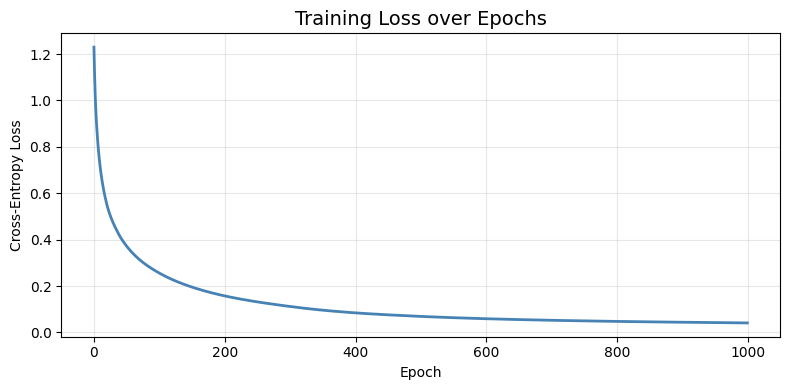


📊 Loss plot saved as training_loss.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────
# STEP 1: DATA PRE-PROCESSING
# ─────────────────────────────────────────────

def normalize(X):
    """Scale features so each has mean=0 and std=1 (Z-score normalization)."""
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0)
    return (X - mean) / (std + 1e-8)   # +1e-8 avoids division by zero

def one_hot_encode(y, num_classes):
    """Convert integer labels [0,1,2] → one-hot rows [[1,0,0],[0,1,0],[0,0,1]]."""
    n = len(y)
    encoded = np.zeros((n, num_classes))
    encoded[np.arange(n), y] = 1
    return encoded

# Load Iris dataset
iris   = load_iris()
X_raw  = iris.data          # shape (150, 4)
y_raw  = iris.target        # shape (150,) — values 0, 1, 2

X = normalize(X_raw)
Y = one_hot_encode(y_raw, num_classes=3)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Input features   : {X_train.shape[1]}")
print(f"Output classes   : {Y_train.shape[1]}")


# ─────────────────────────────────────────────
# STEP 2: ACTIVATION FUNCTIONS
# ─────────────────────────────────────────────

def relu(z):
    """ReLU: max(0, z) — used in hidden layers."""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU: 1 if z>0 else 0."""
    return (z > 0).astype(float)

def softmax(z):
    """Softmax: converts raw scores → probabilities that sum to 1."""
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # subtract max for numerical stability
    return e_z / np.sum(e_z, axis=1, keepdims=True)


# ─────────────────────────────────────────────
# STEP 3: MLP CLASS
# ─────────────────────────────────────────────

class MLP:
    """
    Multi-Layer Perceptron with:
      • Input layer  : 4 neurons  (one per Iris feature)
      • Hidden layer1: 16 neurons (ReLU)
      • Hidden layer2: 8 neurons  (ReLU)
      • Output layer : 3 neurons  (Softmax → probabilities)
    """

    def __init__(self, input_size=4, hidden1=16, hidden2=8, output_size=3, lr=0.01):
        self.lr = lr  # learning rate

        # ── Weight Initialization (He initialization — good for ReLU) ──
        # Shape notation: (fan_in, fan_out)
        self.W1 = np.random.randn(input_size, hidden1) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden1))

        self.W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2 / hidden1)
        self.b2 = np.zeros((1, hidden2))

        self.W3 = np.random.randn(hidden2, output_size) * np.sqrt(2 / hidden2)
        self.b3 = np.zeros((1, output_size))

    # ── FORWARD PASS ──────────────────────────────────────────────────
    def forward(self, X):
        """
        Pass input through all layers to get predictions.
        We store intermediate values (Z, A) needed for backprop.
        """
        # Hidden layer 1
        self.Z1 = X  @ self.W1 + self.b1   # linear combination
        self.A1 = relu(self.Z1)             # activation

        # Hidden layer 2
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = relu(self.Z2)

        # Output layer
        self.Z3 = self.A2 @ self.W3 + self.b3
        self.A3 = softmax(self.Z3)          # probabilities

        return self.A3

    # ── LOSS FUNCTION ─────────────────────────────────────────────────
    def compute_loss(self, Y_pred, Y_true):
        """
        Cross-Entropy Loss: penalises confident wrong predictions heavily.
        Loss = -mean( sum( Y_true * log(Y_pred) ) )
        """
        n = Y_true.shape[0]
        log_probs = -np.log(Y_pred + 1e-8)   # +1e-8 avoids log(0)
        loss = np.sum(Y_true * log_probs) / n
        return loss

    # ── BACKWARD PASS (BACKPROPAGATION) ───────────────────────────────
    def backward(self, X, Y_true):
        """
        Compute gradients using the chain rule, layer by layer — backwards.
        Then update all weights and biases.
        """
        n = X.shape[0]

        # --- Output layer gradient ---
        # For softmax + cross-entropy:
        dZ3 = self.A3 - Y_true            # (n, 3)
        dW3 = self.A2.T @ dZ3 / n
        db3 = np.sum(dZ3, axis=0, keepdims=True) / n

        # --- Hidden layer 2 gradient ---
        dA2 = dZ3 @ self.W3.T
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = self.A1.T @ dZ2 / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        # --- Hidden layer 1 gradient ---
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = X.T @ dZ1 / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        # --- Update weights (gradient descent) ---
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    # ── TRAINING LOOP ─────────────────────────────────────────────────
    def train(self, X, Y, epochs=1000, print_every=100):
        self.loss_history = []

        for epoch in range(1, epochs + 1):
            Y_pred = self.forward(X)
            loss   = self.compute_loss(Y_pred, Y)
            self.backward(X, Y)
            self.loss_history.append(loss)

            if epoch % print_every == 0:
                acc = self.accuracy(X, Y)
                print(f"Epoch {epoch:4d}/{epochs}  |  Loss: {loss:.4f}  |  Accuracy: {acc*100:.1f}%")

    # ── EVALUATION ────────────────────────────────────────────────────
    def predict(self, X):
        """Return class index with highest probability."""
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, Y_true):
        preds = self.predict(X)
        labels = np.argmax(Y_true, axis=1)
        return np.mean(preds == labels)


# ─────────────────────────────────────────────
# STEP 4: TRAIN & EVALUATE
# ─────────────────────────────────────────────

np.random.seed(42)
model = MLP(input_size=4, hidden1=16, hidden2=8, output_size=3, lr=0.05)

print("\n Training Started...\n")
model.train(X_train, Y_train, epochs=1000, print_every=100)

train_acc = model.accuracy(X_train, Y_train)
test_acc  = model.accuracy(X_test,  Y_test)

print(f"\n Final Train Accuracy : {train_acc*100:.1f}%")
print(f" Final Test  Accuracy : {test_acc*100:.1f}%")


# ─────────────────────────────────────────────
# STEP 5: PLOT TRAINING LOSS
# ─────────────────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='steelblue', linewidth=2)
plt.title("Training Loss over Epochs", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
print("\n📊 Loss plot saved as training_loss.png")